In [1]:
SUBJECT_IDS = list(range(1, 11)) # first ten
# SUBJECT_IDS = list(range(1, 110)) # full

# executed
RUNS_FOR_TRAINING = [3, 7]
RUNS_FOR_TESTING = [11]
# # motor imagery
# RUNS_FOR_TRAINING = [4, 8]
# RUNS_FOR_TESTING = [12]

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import mne
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

In [3]:
# 1. Silence MNE logs and suppress deprecation warnings
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore", category=FutureWarning)

def load_and_epoch(subject_id: int, runs: list, tmin=0.5, tmax=3.5, l_freq=8.0, h_freq=30.0, target_sfreq=160.0):
    file_paths = mne.datasets.eegbci.load_data(subjects=subject_id, runs=runs, update_path=False, verbose=False)
    
    raws = []
    for f in file_paths:
        r = mne.io.read_raw_edf(f, preload=True, verbose=False)
        mne.datasets.eegbci.standardize(r)
        raws.append(r)
    
    montage = mne.channels.make_standard_montage('colin27_1005')
    raw = mne.concatenate_raws(raws, verbose=False)
    raw.set_montage(montage, match_case=False)
    
    # 1. Enforce uniform sampling rate across all subjects
    if raw.info['sfreq'] != target_sfreq:
        raw.resample(target_sfreq, verbose=False)
    
    # 2. Bandpass filter
    raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge', verbose=False)
    
    # 3. Parse annotations
    events, event_dict = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2}, verbose=False)
    
    epochs = mne.Epochs(
        raw, events, event_id=event_dict, 
        tmin=tmin, tmax=tmax, baseline=None, 
        preload=True, verbose=False
    )
    
    # Ensure exact sample length (slicing guarantees 481 points in edge rounding cases)
    X = epochs.get_data(copy=False)[:, :, :481]
    y = epochs.events[:, -1] - 1
    
    return epochs, X, y

In [4]:
# 2. Cache the data to avoid reading EDF files many separate times
print(f"Caching data for Subjects {SUBJECT_IDS[0]}-{SUBJECT_IDS[-1]}...")
train_data_cache = {}
test_data_cache = {}

for sub in SUBJECT_IDS:
    _, X_tr, y_tr = load_and_epoch(sub, RUNS_FOR_TRAINING)
    _, X_te, y_te = load_and_epoch(sub, RUNS_FOR_TESTING)
    train_data_cache[sub] = (X_tr, y_tr)
    test_data_cache[sub] = (X_te, y_te)

Caching data for Subjects 1-10...


c:\Users\jason\Projects\ntab-eeg-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# 3. Execute Leave-One-Subject-Out (LOSO) Evaluation
loso_records = []

print("\n=== Starting Inter-Subject (LOSO) Benchmark: CSP vs RG ===")
for test_sub in SUBJECT_IDS:
    train_subs = [s for s in SUBJECT_IDS if s != test_sub]
    
    # Pool Runs 3 & 7 from the 108 training subjects
    X_train_pooled = np.concatenate([train_data_cache[s][0] for s in train_subs], axis=0)
    y_train_pooled = np.concatenate([train_data_cache[s][1] for s in train_subs], axis=0)
    
    # Retrieve Run 11 for the held-out test subject
    X_test_heldout, y_test_heldout = test_data_cache[test_sub]
    
    # Pipeline 1: CSP + LDA
    pipe_csp = Pipeline([
        ("CSP", CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
        ("LDA", LinearDiscriminantAnalysis())
    ])
    pipe_csp.fit(X_train_pooled, y_train_pooled)
    acc_csp = pipe_csp.score(X_test_heldout, y_test_heldout)

    # Pipeline 2: Riemannian Geometry + Logistic Regression
    pipe_rg = Pipeline([
        ("Covariances", Covariances(estimator='lwf')),
        ("TangentSpace", TangentSpace(metric='riemann')),
        ("LR", LogisticRegression(solver="lbfgs", max_iter=1000))
    ])
    pipe_rg.fit(X_train_pooled, y_train_pooled)
    acc_rg = pipe_rg.score(X_test_heldout, y_test_heldout)
    
    loso_records.append({
        "Subject": f"S{test_sub:03d}",
        "CSP_Accuracy": acc_csp,
        "RG_Accuracy": acc_rg
    })
    
    print(f"Held-out S{test_sub:03d} | CSP: {acc_csp:6.2%} | RG: {acc_rg:6.2%} (Test trials: {len(y_test_heldout)})")


=== Starting Inter-Subject (LOSO) Benchmark: CSP vs RG ===
Held-out S001 | CSP: 53.33% | RG: 66.67% (Test trials: 15)
Held-out S002 | CSP: 53.33% | RG: 60.00% (Test trials: 15)
Held-out S003 | CSP: 60.00% | RG: 53.33% (Test trials: 15)
Held-out S004 | CSP: 53.33% | RG: 53.33% (Test trials: 15)
Held-out S005 | CSP: 53.33% | RG: 46.67% (Test trials: 15)
Held-out S006 | CSP: 66.67% | RG: 46.67% (Test trials: 15)
Held-out S007 | CSP: 53.33% | RG: 53.33% (Test trials: 15)
Held-out S008 | CSP: 46.67% | RG: 46.67% (Test trials: 15)
Held-out S009 | CSP: 93.33% | RG: 73.33% (Test trials: 15)
Held-out S010 | CSP: 46.67% | RG: 46.67% (Test trials: 15)



Cohort Size: 10 subjects evaluated
CSP+LDA Mean: 58.00% ± 4.34% SEM (p = 4.9116e-02)
RG+LR Mean:   54.67% ± 2.95% SEM (p = 7.3948e-02)
Paired Difference (RG - CSP): -3.33%
Paired t-test: t(9) = -1.000, p = 3.4344e-01


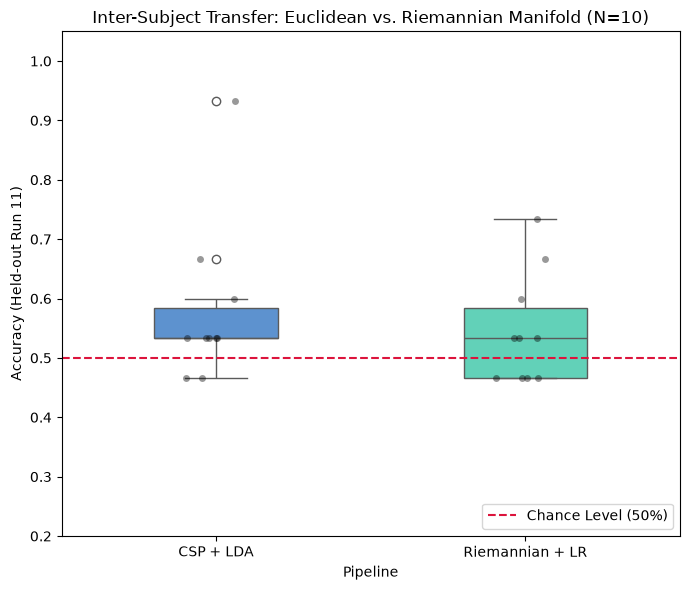

In [6]:
# 4. Summary and Visualization with Statistical Significance
df_loso = pd.DataFrame(loso_records)
n = len(df_loso)

# Compute basic stats
mean_csp = df_loso['CSP_Accuracy'].mean()
sem_csp = df_loso['CSP_Accuracy'].std(ddof=1) / np.sqrt(n)

mean_rg = df_loso['RG_Accuracy'].mean()
sem_rg = df_loso['RG_Accuracy'].std(ddof=1) / np.sqrt(n)

# Inferential stats against 50% chance
t_csp, p_csp = stats.ttest_1samp(df_loso['CSP_Accuracy'], popmean=0.50)
t_rg, p_rg = stats.ttest_1samp(df_loso['RG_Accuracy'], popmean=0.50)

# Paired test: Did Riemannian significantly beat CSP?
t_paired, p_paired = stats.ttest_rel(df_loso['RG_Accuracy'], df_loso['CSP_Accuracy'])

print("\n" + "=" * 55)
print(f"Cohort Size: {n} subjects evaluated")
print(f"CSP+LDA Mean: {mean_csp:.2%} ± {sem_csp:.2%} SEM (p = {p_csp/2:.4e})")
print(f"RG+LR Mean:   {mean_rg:.2%} ± {sem_rg:.2%} SEM (p = {p_rg/2:.4e})")
print(f"Paired Difference (RG - CSP): {(mean_rg - mean_csp):.2%}")
print(f"Paired t-test: t({n-1}) = {t_paired:.3f}, p = {p_paired:.4e}")
print("=" * 55)

# Melt DataFrame for Seaborn
df_melt = df_loso.melt(id_vars=["Subject"], value_vars=["CSP_Accuracy", "RG_Accuracy"], 
                       var_name="Pipeline", value_name="Accuracy")
df_melt["Pipeline"] = df_melt["Pipeline"].replace({"CSP_Accuracy": "CSP + LDA", "RG_Accuracy": "Riemannian + LR"})

# Visualization
plt.figure(figsize=(7, 6))
sns.boxplot(x="Pipeline", y="Accuracy", data=df_melt, palette=["#4A90E2", "#50E3C2"], width=0.4)
sns.stripplot(x="Pipeline", y="Accuracy", data=df_melt, color="black", alpha=0.4, jitter=0.1)

plt.axhline(0.50, color="crimson", linestyle="--", linewidth=1.5, label="Chance Level (50%)")
plt.ylim(0.2, 1.05)
plt.ylabel("Accuracy (Held-out Run 11)")
plt.title(f"Inter-Subject Transfer: Euclidean vs. Riemannian Manifold (N={n})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()